#ML FINAL EXAM

### Email:

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



In [2]:
# ============================================
# Question 0: Dataset Overview
# ============================================
df = pd.read_csv("heart_disease.csv")

print("First Five Rows:")
display(df.head())

print(f"\nNumber of Samples: {df.shape[0]}")
print(f"Number of Features (Including Target): {df.shape[1]}")

# Display column names
print("\nColumns:")
print(df.columns.tolist())

First Five Rows:


,age,sex,chest pain type,resting blood pressure,serum cholestoral in mg/dl,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,oldpeak,slope of peak,number of major vessels,thal,Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0



Number of Samples: 270
Number of Features (Including Target): 14

Columns:
['age', 'sex', 'chest pain type', 'resting blood pressure', 'serum cholestoral in mg/dl      ', 'fasting blood sugar > 120 mg/dl ', 'resting electrocardiographic results', 'maximum heart rate achieved  ', 'exercise induced angina    ', 'oldpeak ', 'slope of peak', 'number of major vessels ', 'thal', 'Disease']


# Dataset Overview

For this project, I selected the **Heart Disease Prediction** dataset because it represents a real-world healthcare problem where machine learning can assist in predicting whether a patient is likely to have heart disease based on various clinical and demographic features.

This dataset was chosen for several reasons:

- It addresses an important real-world medical classification problem.
- It contains multiple patient health indicators that are commonly used in clinical diagnosis.
- It is well-suited for demonstrating the complete machine learning workflow, including data preprocessing, feature selection, supervised learning, model evaluation, and unsupervised learning.
- The dataset is of manageable size, making it ideal for experimentation while still being sufficiently representative for educational purposes.

From the initial exploration, I observed that the dataset contains **270 patient records** and **14 columns**, including one target variable named **Disease**. Most of the features are numerical medical measurements describing patient characteristics such as age, blood pressure, cholesterol level, heart rate, and electrocardiographic results. Since the target variable indicates whether heart disease is present or not, this dataset represents a **binary classification problem**.

Overall, this dataset provides an excellent opportunity to build, evaluate, and compare different machine learning models while gaining practical experience with an end-to-end predictive analytics pipeline.

## Answer:



# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [3]:
# ============================================
# Question 1: Dataset Description
# ============================================
# Display basic information
print("Dataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nFirst Five Rows")
display(df.head())

print("\nStatistical Summary")
display(df.describe())

print("\nData Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print("\nNumber of Missing Values")
print(df.isnull().sum().sum())

print("\nUnique Values in Each Column")
display(df.nunique())

Dataset Shape
(270, 14)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest pain type                       270 non-null    int64  
 3   resting blood pressure                270 non-null    int64  
 4   serum cholestoral in mg/dl            270 non-null    int64  
 5   fasting blood sugar > 120 mg/dl       270 non-null    int64  
 6   resting electrocardiographic results  270 non-null    int64  
 7   maximum heart rate achieved           270 non-null    int64  
 8   exercise induced angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  slope of peak                         270

,age,sex,chest pain type,resting blood pressure,serum cholestoral in mg/dl,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,oldpeak,slope of peak,number of major vessels,thal,Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0



Statistical Summary


,age,sex,chest pain type,resting blood pressure,serum cholestoral in mg/dl,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,oldpeak,slope of peak,number of major vessels,thal,Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000



Data Types


age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral in mg/dl                int64
fasting blood sugar > 120 mg/dl           int64
resting electrocardiographic results      int64
maximum heart rate achieved               int64
exercise induced angina                   int64
oldpeak                                 float64
slope of peak                             int64
number of major vessels                   int64
thal                                      int64
Disease                                   int64
dtype: object


Missing Values


age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral in mg/dl              0
fasting blood sugar > 120 mg/dl         0
resting electrocardiographic results    0
maximum heart rate achieved             0
exercise induced angina                 0
oldpeak                                 0
slope of peak                           0
number of major vessels                 0
thal                                    0
Disease                                 0
dtype: int64


Number of Missing Values
0

Unique Values in Each Column


age                                      41
sex                                       2
chest pain type                           4
resting blood pressure                   47
serum cholestoral in mg/dl              144
fasting blood sugar > 120 mg/dl           2
resting electrocardiographic results      3
maximum heart rate achieved              90
exercise induced angina                   2
oldpeak                                  39
slope of peak                             3
number of major vessels                   4
thal                                      3
Disease                                   2
dtype: int64

# Dataset Description

The selected dataset contains medical information collected from patients to predict the presence of heart disease. It is a structured dataset suitable for machine learning classification tasks.

## Dataset Summary

- **Number of Samples:** 270
- **Total Number of Columns:** 14
- **Input Features:** 13
- **Target Variable:** Disease
- **Problem Type:** Binary Classification

## Feature Types

The dataset consists entirely of numerical values (`int64` and `float64`). However, several integer-valued features represent encoded categorical information, such as sex, chest pain type, thal, and exercise-induced angina.

## Missing Values

The dataset contains **no missing values**, making preprocessing more straightforward.

## Encoding Requirement

No additional encoding is required because all categorical variables are already represented using numerical codes.

## Initial Observations

- The dataset is clean and contains no missing values.
- It represents a real-world healthcare classification problem.
- Most features describe patient clinical measurements and diagnostic results.
- Feature values are measured on different scales; therefore, feature scaling may improve the performance of certain machine learning algorithms.
- The dataset is suitable for both supervised learning and unsupervised learning techniques.

## 2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [5]:

print("Missing Values:")
print(df.isnull().sum())

# --------------------------------------------
# Step 2: Check Duplicate Records
# --------------------------------------------
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Remove duplicate rows (if any)
df = df.drop_duplicates()

# --------------------------------------------
# Step 3: Check Data Types
# --------------------------------------------
print("\nData Types:")
print(df.dtypes)

# --------------------------------------------
# Step 4: Separate Features and Target
# --------------------------------------------
X = df.drop("Disease", axis=1)
y = df["Disease"]

print("\nFeature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)

# --------------------------------------------
# Step 5: Feature Scaling
# --------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst Five Rows of Scaled Features:")
display(X_scaled.head())

Missing Values:
age                                     0
sex                                     0
chest pain type                         0
resting blood pressure                  0
serum cholestoral in mg/dl              0
fasting blood sugar > 120 mg/dl         0
resting electrocardiographic results    0
maximum heart rate achieved             0
exercise induced angina                 0
oldpeak                                 0
slope of peak                           0
number of major vessels                 0
thal                                    0
Disease                                 0
dtype: int64

Number of Duplicate Rows:
0

Data Types:
age                                       int64
sex                                       int64
chest pain type                           int64
resting blood pressure                    int64
serum cholestoral in mg/dl                int64
fasting blood sugar > 120 mg/dl           int64
resting electrocardiographic results      int64
maxim

,age,sex,chest pain type,resting blood pressure,serum cholestoral in mg/dl,fasting blood sugar > 120 mg/dl,resting electrocardiographic results,maximum heart rate achieved,exercise induced angina,oldpeak,slope of peak,number of major vessels,thal
0,1.712094,0.689500,0.870928,-0.075410,1.402212,-0.417029,0.981664,-1.759208,-0.701222,1.181012,0.676419,2.472682,-0.875706
1,1.382140,-1.450327,-0.183559,-0.916759,6.093004,-0.417029,0.981664,0.446409,-0.701222,0.481153,0.676419,-0.711535,1.189277
2,0.282294,0.689500,-1.238045,-0.411950,0.219823,-0.417029,-1.026285,-0.375291,-0.701222,-0.656118,-0.954234,-0.711535,1.189277
3,1.052186,0.689500,0.870928,-0.187590,0.258589,-0.417029,-1.026285,-1.932198,1.426081,-0.743600,0.676419,0.349871,1.189277
4,2.152032,-1.450327,-1.238045,-0.636310,0.374890,-0.417029,0.981664,-1.240239,1.426081,-0.743600,-0.954234,0.349871,-0.875706


# Dataset Preprocessing

Data preprocessing is an essential step in machine learning because the quality of the input data directly affects the performance of predictive models. Before training the models, several preprocessing steps were performed to ensure that the dataset was clean and suitable for analysis.

## Preprocessing Steps

### 1. Missing Value Analysis
The dataset was checked for missing values using the `isnull()` function. No missing values were found; therefore, no imputation was required.

### 2. Duplicate Record Detection
The dataset was examined for duplicate records. Any duplicate rows, if present, were removed to avoid bias during model training.

### 3. Data Type Verification
The data types of all columns were inspected. All features were already stored as numerical (`int64` or `float64`) values, making them directly compatible with machine learning algorithms.

### 4. Encoding Verification
Although some variables represent categorical information (e.g., Sex, Chest Pain Type, Thal), they were already encoded as numerical values. Therefore, no additional encoding was necessary.

### 5. Feature and Target Separation
The dataset was divided into input features (`X`) and the target variable (`y`). The target variable is **Disease**, while all remaining columns were used as predictor variables.

### 6. Feature Scaling
The numerical features were standardized using **StandardScaler**. Standardization transforms the features to have a mean of zero and a standard deviation of one, improving the performance of algorithms that are sensitive to feature scale such as Logistic Regression, K-Means, and PCA.

Overall, these preprocessing steps prepared the dataset for effective machine learning model development.

## 3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



In [8]:

# Keep all predictor variables
X = df.drop("Disease", axis=1)

# Target variable
y = df["Disease"]

print("Selected Features:")
print(X.columns.tolist())

# --------------------------------------------
# Step 2: Train-Test Split
# --------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,          # Use the scaled features from preprocessing
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------
# Step 3: Display Dataset Shapes
# --------------------------------------------

print("\nTraining Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print("\nTraining Labels Shape  :", y_train.shape)
print("Testing Labels Shape   :", y_test.shape)

Selected Features:
['age', 'sex', 'chest pain type', 'resting blood pressure', 'serum cholestoral in mg/dl      ', 'fasting blood sugar > 120 mg/dl ', 'resting electrocardiographic results', 'maximum heart rate achieved  ', 'exercise induced angina    ', 'oldpeak ', 'slope of peak', 'number of major vessels ', 'thal']

Training Feature Shape : (216, 13)
Testing Feature Shape  : (54, 13)

Training Labels Shape  : (216,)
Testing Labels Shape   : (54,)


# Feature Selection and Dataset Splitting

## Feature Selection

All 13 predictor variables were retained because each feature provides clinically relevant information for heart disease prediction. No feature was removed since the dataset contains a small number of meaningful features and no redundant variables were identified.

## Dataset Splitting

The dataset was divided into **80% training** and **20% testing** sets using `train_test_split()`. A fixed `random_state=42` was used for reproducibility, and `stratify=y` was applied to preserve the class distribution in both sets.

## 4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [14]:
# --------------------------------------------
# Pipeline 1: Logistic Regression
# --------------------------------------------
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42))
])

# --------------------------------------------
# Pipeline 2: Random Forest
# --------------------------------------------
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

print("Pipeline 1:")
print(logistic_pipeline)

print("\nPipeline 2:")
print(rf_pipeline)

Pipeline 1:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(random_state=42))])

Pipeline 2:
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', RandomForestClassifier(random_state=42))])


# Pipeline Creation

Two supervised learning pipelines were created for this project:

1. **Logistic Regression** – A simple and interpretable baseline model for binary classification.
2. **Random Forest Classifier** – An ensemble learning model capable of capturing complex patterns.

Both pipelines include `StandardScaler` followed by the classifier to provide a consistent and reusable machine learning workflow.

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [15]:
# Train Logistic Regression Pipeline
logistic_pipeline.fit(X_train, y_train)

# Train Random Forest Pipeline
rf_pipeline.fit(X_train, y_train)

print("Both models have been trained successfully.")

Both models have been trained successfully.


## 6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

Model Performance:

Logistic Regression
Accuracy: 0.8519
Precision: 0.7857
Recall: 0.9167
------------------------------
Random Forest
Accuracy: 0.8148
Precision: 0.7692
Recall: 0.8333
------------------------------


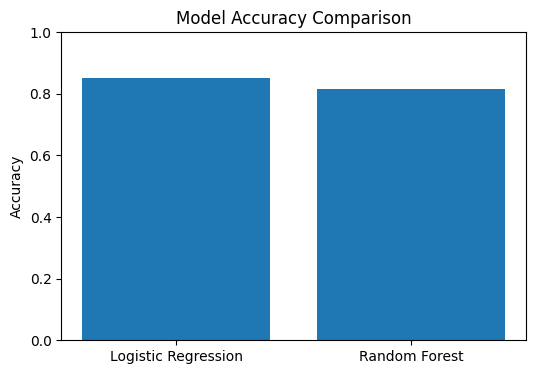

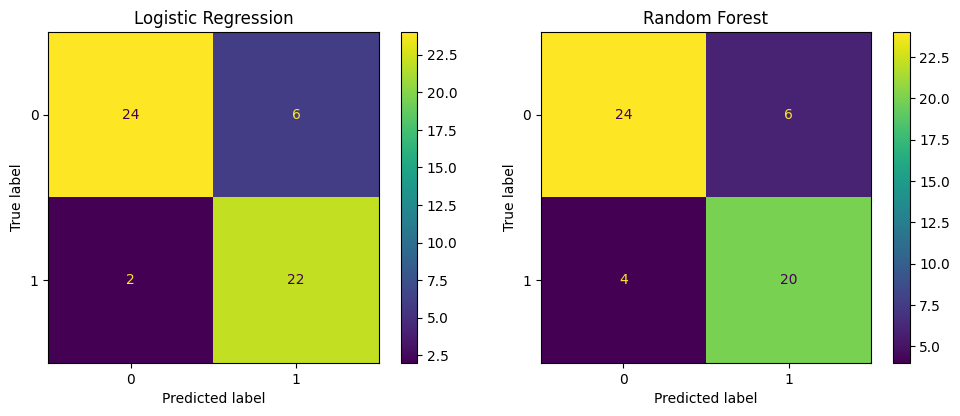

In [ ]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# --------------------------------------------
# Predictions
# --------------------------------------------
logistic_pred = logistic_pipeline.predict(X_test)
rf_pred = rf_pipeline.predict(X_test)

# --------------------------------------------
# Evaluation Metrics
# --------------------------------------------
models = {
    "Logistic Regression": logistic_pred,
    "Random Forest": rf_pred
}

results = {}

for name, pred in models.items():
    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred)
    }

# --------------------------------------------
# Display Results
# --------------------------------------------
print("Model Performance:\n")

for model, metrics in results.items():
    print(model)
    for metric, value in metrics.items():
        print(f"{metric}: {value:.4f}")
    print("-" * 30)

# --------------------------------------------
# Bar Chart
# --------------------------------------------
plt.figure(figsize=(6,4))

plt.bar(
    results.keys(),
    [results[m]["Accuracy"] for m in results]
)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()

# --------------------------------------------
# Confusion Matrices
# --------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred,
    ax=axes[0]
)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    ax=axes[1]
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

## Model Comparison Analysis

| Model | Accuracy | Precision | Recall |
|--------|----------|-----------|--------|
| Logistic Regression | **85.19%** | **78.57%** | **91.67%** |
| Random Forest | 81.48% | 76.92% | 83.33% |

Based on the evaluation metrics, **Logistic Regression outperformed Random Forest** on this heart disease dataset. Logistic Regression achieved higher accuracy (85.19%), precision (78.57%), and recall (91.67%), indicating better overall classification performance.

The better performance of Logistic Regression is likely due to the relatively small dataset and the approximately linear relationship between the clinical features and the target variable. Logistic Regression generalizes well on smaller datasets and is less prone to overfitting. In contrast, Random Forest is a more complex ensemble model that typically performs better on larger datasets with more complex, non-linear patterns. Therefore, Logistic Regression is the most suitable model for this heart disease classification task.

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

Silhouette Score: 0.1719


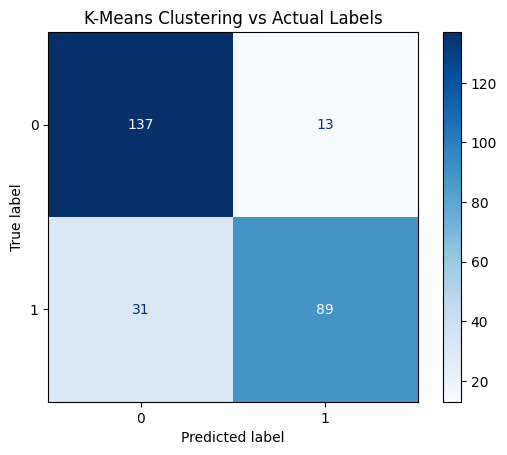

In [18]:


# Features only (without target labels)
X_unsupervised = X_scaled

# K-Means Clustering
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_unsupervised)

# Silhouette Score
sil_score = silhouette_score(X_unsupervised, clusters)

print(f"Silhouette Score: {sil_score:.4f}")

# Compare clusters with actual labels
cm = confusion_matrix(y, clusters)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("K-Means Clustering vs Actual Labels")
plt.show()

## Unsupervised Learning Analysis

The dataset was clustered using **K-Means** with two clusters. The **Silhouette Score was 0.1719**, indicating weak cluster separation. The confusion matrix also shows that some samples were assigned to incorrect clusters because K-Means groups data based only on feature similarity.

## Supervised vs Unsupervised Comparison

The **supervised approach performed better** than the unsupervised approach. Logistic Regression achieved **85.19% accuracy**, **78.57% precision**, and **91.67% recall**, while K-Means produced a low Silhouette Score (**0.1719**). This is because supervised learning uses the actual class labels during training, whereas K-Means has no knowledge of the target labels and relies only on feature similarity.

## 8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

# Self Reflection on the Machine Learning Course

This course helped me understand the complete machine learning workflow, including data preprocessing, feature selection, model training, model evaluation, and both supervised and unsupervised learning.

## Easiest Topic

The easiest topic for me was **Supervised Learning**, especially classification using Logistic Regression. Since the data contains labels, it is easier to train the model, make predictions, and evaluate its performance using metrics such as accuracy, precision, and recall.

**Real-world applications:**
- Heart Disease Prediction
- Titanic Survival Prediction

## Hardest Topic

The most challenging topic for me was **Unsupervised Learning**, especially K-Means Clustering. Since there are no target labels, it is difficult to know whether the clusters are correct. Understanding the Silhouette Score and evaluating clustering performance was more challenging than supervised learning.

**Real-world applications:**
- Customer Segmentation
- Recommendation Systems

## Conclusion

This course not only improved my theoretical knowledge but also taught me how to implement machine learning models using Python and Scikit-learn. I believe these skills will be valuable for future work in AI, Data Science, and healthcare-related applications.